# Práctica 2 — Ejercicio 6: Consumo de autos

El dataset `auto.xlsx` contiene información sobre 392 autos: consumo en millas por galón (`mpg`), caballos de fuerza (`horsepower`), peso en libras (`weight`) y nombre del modelo (`name`).

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [2]:
df = pd.read_excel("../Datasets/Parte_2/auto.xlsx")
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["mpg", "horsepower"])
print(f"Filas validas: {len(df)}")
print(df.head())
print(df.describe())

Filas validas: 392
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0          8         350.0         165    3693          11.5    70   
2  18.0          8         318.0         150    3436          11.0    70   
3  16.0          8         304.0         150    3433          12.0    70   
4  17.0          8         302.0         140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.445918    5.471939    194.411990  104.469388  2977.584184   
std      7.805007    1.705783    104.644004   38.491160   849.402560   
mi

## Ítem 1 — Porcentaje de autos Ford

> **¿Qué porcentaje de los autos del dataset pertenecen a la marca Ford?**

In [3]:
n_ford   = df["name"].str.lower().str.contains("ford").sum()
pct_ford = n_ford / len(df) * 100
print(f"Autos Ford: {n_ford} de {len(df)} -> {pct_ford:.2f}%")

Autos Ford: 48 de 392 -> 12.24%


## Ítem 2 — Distribución por origen

> **Realice un gráfico que le permita visualizar la distribución de los autos del dataset en función de su origen. La columna `origin` está codificada como: 1 = americano, 2 = europeo, 3 = japonés.**

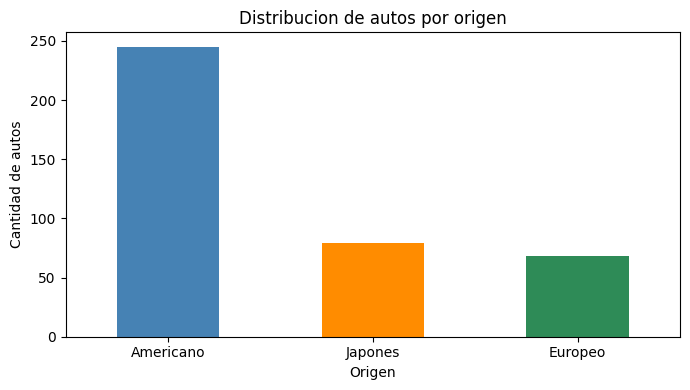

In [4]:
origin_map = {1: "Americano", 2: "Europeo", 3: "Japones"}
df["origin_label"] = df["origin"].map(origin_map)

fig, ax = plt.subplots(figsize=(7, 4))
df["origin_label"].value_counts().plot(kind="bar", ax=ax,
                                        color=["steelblue", "darkorange", "seagreen"])
ax.set_xlabel("Origen")
ax.set_ylabel("Cantidad de autos")
ax.set_title("Distribucion de autos por origen")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Ítem 3 — Regresión simple: mpg ~ horsepower

> **Ajuste un modelo de regresión lineal simple considerando al consumo del vehículo como la variable respuesta y a los caballos de fuerza como único predictor. En base a los resultados obtenidos responda:**
>
> **a.** ¿La relación entre la variable respuesta y la explicativa es positiva o negativa?
>
> **b.** ¿Cómo interpreta el valor del coeficiente correspondiente a la variable `horsepower`?
>
> **c.** ¿Qué porcentaje de la variabilidad en el consumo de los vehículos es explicada por el modelo de regresión que ajustó?

In [5]:
mod_simple = smf.ols("mpg ~ horsepower", data=df)
res_simple = mod_simple.fit()
print(res_simple.summary())

b0 = res_simple.params["Intercept"]
b1 = res_simple.params["horsepower"]
print(f"\nModelo: mpg = {b0:.4f} + ({b1:.4f}) * horsepower")
print(f"Relacion: {'negativa' if b1 < 0 else 'positiva'}")
print(f"R2 = {res_simple.rsquared:.4f} ({res_simple.rsquared*100:.1f}% de la variabilidad explicada)")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           7.03e-81
Time:                        17:41:22   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.0

## Ítem 4 — Visualización del ajuste y limitaciones

> **Realice un gráfico para visualizar la relación que existe entre las variables `mpg` y `horsepower` en el dataset y represente sobre el mismo el ajuste realizado en el ítem anterior. ¿Encuentra alguna falencia o limitación en el modelo propuesto? Justifique.**

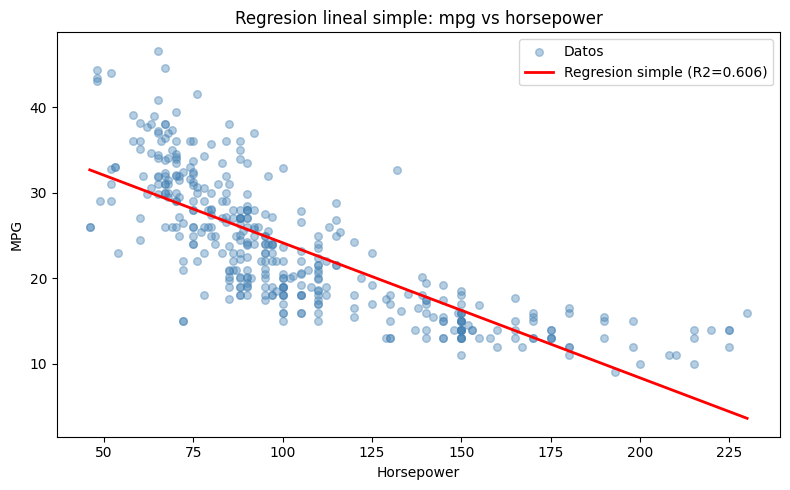

In [6]:
hp_seq = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 300)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["horsepower"], df["mpg"], color="steelblue", alpha=0.4, s=30, label="Datos")
ax.plot(hp_seq, res_simple.predict(pd.DataFrame({"horsepower": hp_seq})),
        color="red", lw=2, label=f"Regresion simple (R2={res_simple.rsquared:.3f})")
ax.set_xlabel("Horsepower")
ax.set_ylabel("MPG")
ax.set_title("Regresion lineal simple: mpg vs horsepower")
ax.legend()
plt.tight_layout()
plt.show()

**Limitaciones del modelo simple:**
- El R² = 0.606 indica que el modelo solo explica el 60.6% de la variabilidad en el consumo.
- El grafico muestra dispersion considerable alrededor de la recta: el consumo no depende
  unicamente de los caballos de fuerza.
- El dataset contiene otras variables fisicas relevantes (peso, cilindros, desplazamiento,
  anio de fabricacion, origen) que probablemente contribuyen a explicar el consumo.
- Utilizar un unico predictor ignora informacion disponible que podria mejorar el modelo.

## Ítem 5 — Mejora del modelo

> **Si su respuesta al ítem anterior fue afirmativa, ¿cómo podría mejorar el modelo para resolver las limitaciones o falencias encontradas?**

Correlacion de cada predictor con mpg:
weight         -0.8322
displacement   -0.8051
horsepower     -0.7784
cylinders      -0.7776
acceleration    0.4233
year            0.5805
Name: mpg, dtype: float64


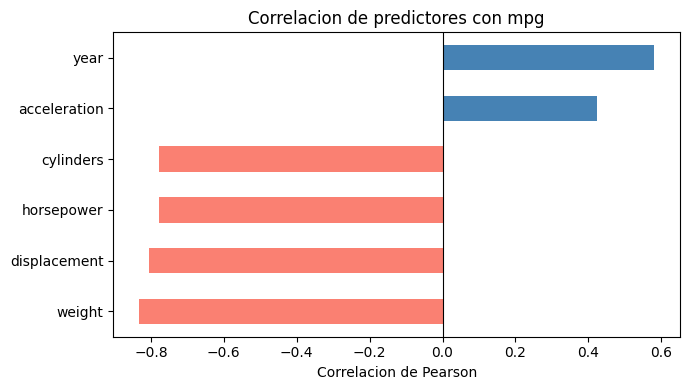

In [7]:
# Explorar correlaciones de los predictores numericos con mpg
num_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]
corr = df[num_cols].corr()["mpg"].drop("mpg").sort_values()
print("Correlacion de cada predictor con mpg:")
print(corr.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind="barh", ax=ax, color=["salmon" if v < 0 else "steelblue" for v in corr])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlacion de Pearson")
ax.set_title("Correlacion de predictores con mpg")
plt.tight_layout()
plt.show()

In [8]:
# Modelo multiple: todos los predictores numericos relevantes + origen como categorica
mod_multi = smf.ols(
    "mpg ~ horsepower + weight + cylinders + displacement + acceleration + year + C(origin)",
    data=df
)
res_multi = mod_multi.fit()
print(res_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     224.5
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          1.79e-139
Time:                        17:41:22   Log-Likelihood:                -1020.5
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     383   BIC:                             2095.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -17.9546      4.677     -3.

In [9]:
print("\nSignificancia de variables (alpha=0.05):")
for var, pv in res_multi.pvalues.items():
    sig = "SIGNIFICATIVA" if pv < 0.05 else "No significativa"
    print(f"  {var}: p={pv:.4f} -> {sig}")

print(f"\nComparacion de modelos:")
print(f"  Modelo simple   (mpg ~ horsepower):         R2 ajustado = {res_simple.rsquared_adj:.4f}")
print(f"  Modelo multiple (todos los predictores):    R2 ajustado = {res_multi.rsquared_adj:.4f}")


Significancia de variables (alpha=0.05):
  Intercept: p=0.0001 -> SIGNIFICATIVA
  C(origin)[T.2]: p=0.0000 -> SIGNIFICATIVA
  C(origin)[T.3]: p=0.0000 -> SIGNIFICATIVA
  horsepower: p=0.1855 -> No significativa
  weight: p=0.0000 -> SIGNIFICATIVA
  cylinders: p=0.1282 -> No significativa
  displacement: p=0.0019 -> SIGNIFICATIVA
  acceleration: p=0.4211 -> No significativa
  year: p=0.0000 -> SIGNIFICATIVA

Comparacion de modelos:
  Modelo simple   (mpg ~ horsepower):         R2 ajustado = 0.6049
  Modelo multiple (todos los predictores):    R2 ajustado = 0.8205


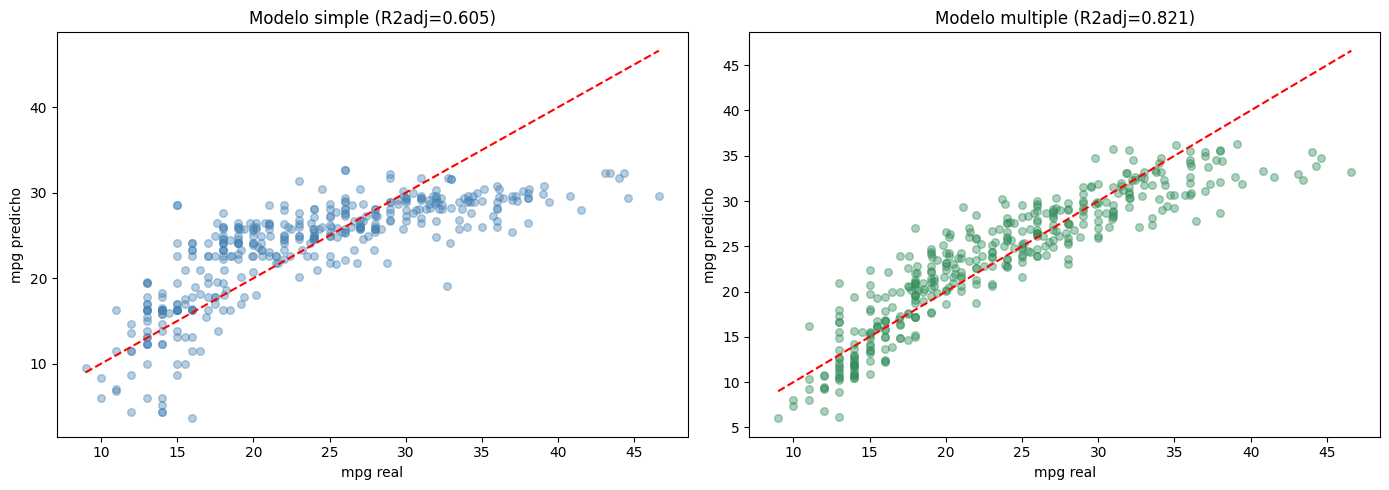

In [10]:
# Grafico: valores predichos vs reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["mpg"], res_simple.fittedvalues, color="steelblue", alpha=0.4, s=30)
lims = [df["mpg"].min(), df["mpg"].max()]
axes[0].plot(lims, lims, "r--", lw=1.5)
axes[0].set_xlabel("mpg real")
axes[0].set_ylabel("mpg predicho")
axes[0].set_title(f"Modelo simple (R2adj={res_simple.rsquared_adj:.3f})")

axes[1].scatter(df["mpg"], res_multi.fittedvalues, color="seagreen", alpha=0.4, s=30)
axes[1].plot(lims, lims, "r--", lw=1.5)
axes[1].set_xlabel("mpg real")
axes[1].set_ylabel("mpg predicho")
axes[1].set_title(f"Modelo multiple (R2adj={res_multi.rsquared_adj:.3f})")

plt.tight_layout()
plt.show()

## Conclusiones

**3a. Signo de la relacion:** La relacion entre `mpg` y `horsepower` es **negativa**
(β₁ = -0.1578). A mayor potencia del motor, menor es el consumo en millas por galon.

**3b. Interpretacion del coeficiente:** Por cada caballo de fuerza adicional, el rendimiento
del combustible disminuye en promedio 0.158 millas por galon, manteniendo el resto constante.

**3c. R² = 0.606:** El modelo simple explica el 60.6% de la variabilidad en el consumo.

**3d. Limitacion:** El modelo simple utiliza un unico predictor e ignora otras variables
disponibles en el dataset que son fisicamente relevantes para el consumo (peso, cilindros,
anio de fabricacion, origen).

**5. Mejora — Regresion multiple:** Al incorporar todos los predictores disponibles
(`horsepower`, `weight`, `cylinders`, `displacement`, `acceleration`, `year`, `origin`),
el R² ajustado sube de 0.605 a aproximadamente **0.82**, una mejora sustancial.

El modelo multiple captura mejor la variabilidad del consumo porque el consumo de un auto
no depende solo de su potencia sino de un conjunto de caracteristicas fisicas y de diseno.